In [22]:
%reset -f
import pandas as pd
df_manuscript = pd.read_excel("/Users/lingyi/Documents/spatial/colocalization/MI_lists/dataset_in_manuscript.xlsx")

# df_high_low_aCAF = df_manuscript[(df_manuscript["APOD_pct_gt1"] >= 10) & (df_manuscript["COL11A1_pct_gt1"] >= 25) & (df_manuscript["EPCAM_pct_gt1"] >= 25) & (df_manuscript["EPCAM_pct_gt1"] < 95)  & (df_manuscript["Total_spots"] >= 1200) ]


df_filter_low_aCAF = df_manuscript[(df_manuscript["LUM_pct_gt1"] >= 40) & (df_manuscript["COL11A1_pct_gt1"] < 10) & (df_manuscript["EPCAM_pct_gt1"] >= 25) & (df_manuscript["EPCAM_pct_gt1"] < 95)  & (df_manuscript["Total_spots"] >= 1200) ]
df_filter_low_aCAF

,SampleID,dataset_name,label,cancer_type,COL11A1_pct_gt1,APOD_pct_gt1,LUM_pct_gt1,TREM2_pct_gt1,MS4A1_pct_gt1,CCL19_pct_gt1,...,KRT8_pct_gt1,KRT18_pct_gt1,KRT19_pct_gt1,CD3D_pct_gt1,AIF1_pct_gt1,aCAF_metagene_pct_gt1,ASC_metagene_pct_gt1,Immune_metagene_pct_gt1,Tumor_metagene_pct_gt1,Total_spots
10,GSM6433589_093C,GSE210616_breast_spatial,Bassiouni,BC,7.85,23.54,92.54,10.12,0.34,4.65,...,93.61,91.04,84.65,8.09,26.88,4.46,7.75,0.00,73.41,2065
11,GSM6433590_093D,GSE210616_breast_spatial,Bassiouni,BC,7.07,15.61,93.53,5.94,0.07,0.87,...,84.92,66.71,51.37,3.47,17.28,2.60,2.47,0.00,33.09,1499
57,SN048_A416371_Rep1,Valdeolivas_colon_spatial,Valdeolivas,CRC,2.56,0.27,41.48,1.02,0.09,0.31,...,99.51,99.38,97.97,9.32,6.54,0.22,0.00,0.00,91.30,2264
61,SN123_A798015_Rep1,Valdeolivas_colon_spatial,Valdeolivas,CRC,0.24,18.77,70.16,0.67,2.06,1.76,...,42.43,23.55,38.44,0.54,7.63,0.06,14.35,0.00,14.35,1652
65,SN124_A798015_Rep2,Valdeolivas_colon_spatial,Valdeolivas,CRC,0.25,18.93,73.24,1.60,1.36,5.55,...,48.52,32.98,44.70,1.17,11.41,0.06,14.43,0.00,22.81,1622
85,P17,HRA002509_lung/raw/ST-visium_new,Yan,NSCLC,4.21,19.92,92.95,17.67,5.10,9.74,...,94.94,92.28,94.17,7.98,33.08,0.40,10.28,0.05,44.78,4272
99,HT242P1H4-S1Fc1U1Z1B1_1,HTAN_WUSTL/scRNA_vali/raw_spatial,Cui,PDAC,8.04,9.13,53.99,0.52,0.05,0.29,...,99.51,96.04,96.41,0.34,3.72,2.37,0.47,0.00,34.79,3843
102,HT264P1-S1H2Fc2U1Z1Bs1-H2Bs2-Test,HTAN_WUSTL/scRNA_vali/raw_spatial,Cui,PDAC,9.41,14.85,77.80,4.45,0.80,10.31,...,69.31,63.91,75.92,1.70,13.91,1.03,3.72,0.00,42.24,4356
128,Visium_FFPE_Human_Ovarian_Cancer,10X/OV,10X,OV,8.45,48.42,58.64,10.25,3.07,12.26,...,91.31,91.55,NaN,58.46,76.81,2.07,26.23,0.06,73.06,3385
129,CytAssist_FFPE_Protein_Expression_Human_Breast...,10X/BRCA,10X,BRCA,5.14,43.06,48.62,1.64,49.84,43.62,...,60.27,NaN,46.76,32.41,38.43,1.35,7.61,12.19,36.92,4085


In [23]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import importlib
import sys
sys.path.append("/Users/lingyi/Documents/spatial/colocalization/functions")

import tools
importlib.reload(tools)



<module 'tools' from '/Users/lingyi/Documents/spatial/colocalization/functions/tools.py'>

In [24]:
# ============= CONFIGURATION SECTION =============
# Cell population: Always use STROMAL cells (identified by LUM expression)
STROMAL_MARKER = "LUM"  # Marker to identify stromal/fibroblast clusters
Z_THRESHOLD = 0.5  # Threshold for identifying high-expressing clusters
# ==================================================
def identify_clusters_by_expression(adata, genes, z_threshold=0.5):
    """
    Identify clusters highly expressing given gene(s) using z-score thresholding.
    If multiple genes provided, uses average expression.
    Returns clusters with expression > mean + z_threshold * std.
    """
    if isinstance(genes, str):
        genes = [genes]
    
    cluster_means = {}
    
    for cluster in adata.obs['clusters'].unique():
        mask = adata.obs['clusters'] == cluster
        
        # Calculate mean expression across all provided genes
        cluster_expr_values = []
        for gene in genes:
            if gene in adata.var_names:
                expr = adata[mask, gene].X
                if hasattr(expr, "toarray"):
                    expr = expr.toarray()
                expr = np.array(expr).flatten()
                cluster_expr_values.append(np.mean(expr))
        
        # Average across genes
        if len(cluster_expr_values) > 0:
            cluster_means[cluster] = np.mean(cluster_expr_values)
        else:
            cluster_means[cluster] = 0

    # Convert to array for stats
    means = np.array(list(cluster_means.values()))
    mean_all = np.mean(means)
    std_all = np.std(means)

    # Choose clusters above threshold
    high_clusters = [c for c, m in cluster_means.items() if m > (mean_all + z_threshold * std_all)]

    gene_str = ", ".join(genes)
    print(f"\n=== {gene_str} Expression Cluster Scan ===")
    print(f"Cluster Mean Expressions: {cluster_means}")
    print(f"Mean: {mean_all:.3f} | Std: {std_all:.3f} | Threshold: {mean_all + z_threshold*std_all:.3f}")
    print(f"High {gene_str} clusters: {high_clusters}")

    return high_clusters

def calculate_signature_score(adata, gene_list, score_name):
    """Calculate signature score as mean expression of genes in the list"""
    if isinstance(gene_list, str):
        gene_list = [gene_list]
    
    # Use scanpy's built-in subsetting to safely handle gene selection
    present_genes = [gene for gene in gene_list if gene in adata.var_names]
    
    if len(present_genes) == 0:
        raise ValueError(f"None of the genes in {gene_list} found in the dataset")
    
    # Use adata subsetting which handles duplicate gene names properly
    adata_subset = adata[:, present_genes]
    signature_expr = adata_subset.X
    
    if hasattr(signature_expr, 'toarray'):
        signature_expr = signature_expr.toarray()
    
    # Calculate mean across genes (axis=1 for mean across genes for each cell)
    signature_score = np.mean(signature_expr, axis=1)
    adata.obs[score_name] = signature_score
    
    return signature_score

def analyze_stromal_expression_by_tumor_proximity_annotation(adata, radius=200):
    """
    Analyze expression of specified genes in stromal cells based on distance to tumor.
    Returns expression scores in stromal cells near vs far from tumor, and their distances.
    """
    coords = adata.obsm['spatial_um']
    
    # Get tumor spot indices
    tumor_indices = np.where(adata.obs['annotation_tumor'])[0]
    tumor_coords = coords[tumor_indices]

    # For each spot, calculate distance to nearest tumor
    all_distances_to_tumor = []
    for i, coord in enumerate(coords):
        if len(tumor_coords) > 0:
            distances_to_tumors = np.sqrt(np.sum((tumor_coords - coord)**2, axis=1))
            min_distance = np.min(distances_to_tumors)
        else:
            min_distance = np.inf
        all_distances_to_tumor.append(min_distance)
    all_distances_to_tumor = np.array(all_distances_to_tumor)
    
    # Define masks - focus on stromal cells only
    stromal_mask = adata.obs['annotation_stromal'].values
    tumor_mask = adata.obs['annotation_tumor'].values
    other_cells_mask = ~(stromal_mask | tumor_mask)

    # Stromal cells near vs far from tumor
    stromal_near_tumor_mask = stromal_mask & (all_distances_to_tumor <= radius)
    stromal_far_tumor_mask = stromal_mask & (all_distances_to_tumor > radius)
    
    stromal_scores_near_tumor = adata.obs.loc[stromal_near_tumor_mask, 'expression_score'].values
    stromal_scores_far_tumor = adata.obs.loc[stromal_far_tumor_mask, 'expression_score'].values
    
    # compute for ALL OTHER (non-stromal, non-tumor) spots
    other_near_tumor_mask = other_cells_mask & (all_distances_to_tumor <= radius)
    other_far_tumor_mask = other_cells_mask & (all_distances_to_tumor > radius)

    other_scores_near_tumor = adata.obs.loc[other_near_tumor_mask, 'expression_score'].values
    other_scores_far_tumor = adata.obs.loc[other_far_tumor_mask, 'expression_score'].values
    
    # Get distances and stromal expression scores
    stromal_distances = all_distances_to_tumor[stromal_mask]
    stromal_scores = adata.obs.loc[stromal_mask, 'expression_score'].values
    
    return (stromal_scores_near_tumor, stromal_scores_far_tumor, 
            other_scores_near_tumor, other_scores_far_tumor, 
            stromal_distances, stromal_scores)



Processing 12 samples for 8 markers...
Optimized: Load each sample once, calculate all 8 markers

===== GSM6433589_093C =====
  Loading data...


/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:170: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=path, count_file="filtered_feature_bc_matrix.h5",
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarn

Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/GSE210616_breast_spatial/raw/GSM6433589_093C
→ Computed microns_per_pixel = 0.3726 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.8042686, '1': 1.834189, '2': 1.3791701, '3': 1.822748, '4': 2.7945778, '5': 2.4372823, '6': 1.6532726, '7': 3.0538135, '8': 2.8225386, '9': 2.6125925, '10': 1.6144857}
Mean: 2.166 | Std: 0.559 | Threshold: 2.446
High LUM clusters: ['4', '7', '8', '9']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.9345696, '1': 2.1893072, '2': 2.1565871, '3': 2.318771, '4': 2.2059913, '5': 2.3536034, '6': 1.4193236, '7': 1.7534394, '8': 1.730084, '9': 0.93493336, '10': 2.396438}
Mean: 1.945 | Std: 0.433 | Threshold: 2.161
High EPCAM clusters: ['1', '3', '4', '5', '10']
    Processing aCAF markers...
    Processing T cell marker...
    Processing Cytotoxic T cell marker...
    Processing Memor

/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:170: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=path, count_file="filtered_feature_bc_matrix.h5",
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarn

Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/GSE210616_breast_spatial/raw/GSM6433590_093D
→ Computed microns_per_pixel = 0.3723 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.9557188, '1': 2.3847992, '2': 1.5928097, '3': 1.6028584, '4': 2.2542174, '5': 2.0022674, '6': 1.7976744, '7': 1.5288894, '8': 1.9974563, '9': 2.2296562, '10': 1.945305, '11': 1.578475}
Mean: 1.906 | Std: 0.278 | Threshold: 2.045
High LUM clusters: ['1', '4', '9']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.8926957, '1': 1.0545439, '2': 1.8499756, '3': 1.8645188, '4': 1.4143775, '5': 1.5881892, '6': 1.896863, '7': 1.9350768, '8': 1.7532526, '9': 1.2673802, '10': 1.4746462, '11': 1.2275739}
Mean: 1.602 | Std: 0.294 | Threshold: 1.749
High EPCAM clusters: ['0', '2', '3', '6', '7', '8']
    Processing aCAF markers...
    Processing T cell marker...
    Processing Cytotoxic T c

...

Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/10X/BRCA/raw/CytAssist_FFPE_Protein_Expression_Human_Breast_Cancer
→ Computed microns_per_pixel = 0.2548 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 2.0028152, '2': 0.5245664, '3': 0.8260315, '4': 1.2471036, '6': 1.7991252, '8': 0.44615415, '9': 0.59297097, '1': 0.896178, '10': 1.2898735, '11': 1.2009501, '12': 0.80867255, '13': 0.44833773, '5': 0.756528, '7': 1.119604, '14': 0.42500547, '15': 0.46156523, '16': 0.73297286, '17': 1.3218565, '18': 1.1499808, '19': 0.74842924}
Mean: 0.940 | Std: 0.435 | Threshold: 1.158
High LUM clusters: ['0', '4', '6', '10', '11', '17']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 0.18563394, '2': 1.9185473, '3': 1.4599966, '4': 1.1894685, '6': 0.41745815, '8': 1.3873013, '9': 0.18479027, '1': 1.145932, '10': 0.35606596, '11': 0.14451918, '12': 0.3487294, '13': 1.773154

/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:170: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=path, count_file="filtered_feature_bc_matrix.h5",
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarn

Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/10X/BRCA/raw/V1_Breast_Cancer_Block_A_Section_2
→ Computed microns_per_pixel = 0.3100 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.4791002, '1': 2.4420407, '3': 1.1254594, '4': 1.4299481, '5': 1.3241109, '6': 1.5295143, '7': 1.2639621, '8': 1.6430166, '9': 1.7345299, '10': 1.7558092, '11': 1.3852745, '12': 0.90608007, '13': 1.0656335, '14': 1.4782445, '2': 1.8716413}
Mean: 1.496 | Std: 0.361 | Threshold: 1.676
High LUM clusters: ['1', '9', '10', '2']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.2955034, '1': 0.864584, '3': 1.215561, '4': 1.1471416, '5': 1.4806567, '6': 0.92783475, '7': 1.437278, '8': 1.0789282, '9': 1.1801672, '10': 0.816203, '11': 1.2820476, '12': 1.6228664, '13': 1.4422574, '14': 1.0683354, '2': 0.4118656}
Mean: 1.151 | Std: 0.299 | Threshold: 1.301
High EPCAM clusters: ['5', '7',

/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:170: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=path, count_file="filtered_feature_bc_matrix.h5",
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarn

Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/10X/BRCA/raw/Visium_Human_Breast_Cancer
→ Computed microns_per_pixel = 0.3115 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.

=== LUM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 1.3373146, '1': 0.9915179, '3': 0.5936162, '4': 1.0995672, '2': 1.6624211, '5': 0.7590407, '6': 1.3602647, '7': 1.4340824, '8': 0.97759724, '9': 0.89046144, '10': 0.8326001, '11': 0.64816326, '12': 0.358569, '13': 1.2085077, '14': 0.5716324}
Mean: 0.982 | Std: 0.356 | Threshold: 1.160
High LUM clusters: ['0', '2', '6', '7', '13']

=== EPCAM Expression Cluster Scan ===
Cluster Mean Expressions: {'0': 0.6144562, '1': 0.53599644, '3': 0.9861958, '4': 0.658114, '2': 0.18663129, '5': 0.46545762, '6': 0.5207277, '7': 0.5446928, '8': 0.29754764, '9': 0.76603806, '10': 0.5297399, '11': 0.88269246, '12': 0.9988737, '13': 0.5590504, '14': 1.1398325}
Mean: 0.646 | Std: 0.256 | Threshold: 0.774
High EPCAM clusters: ['3'

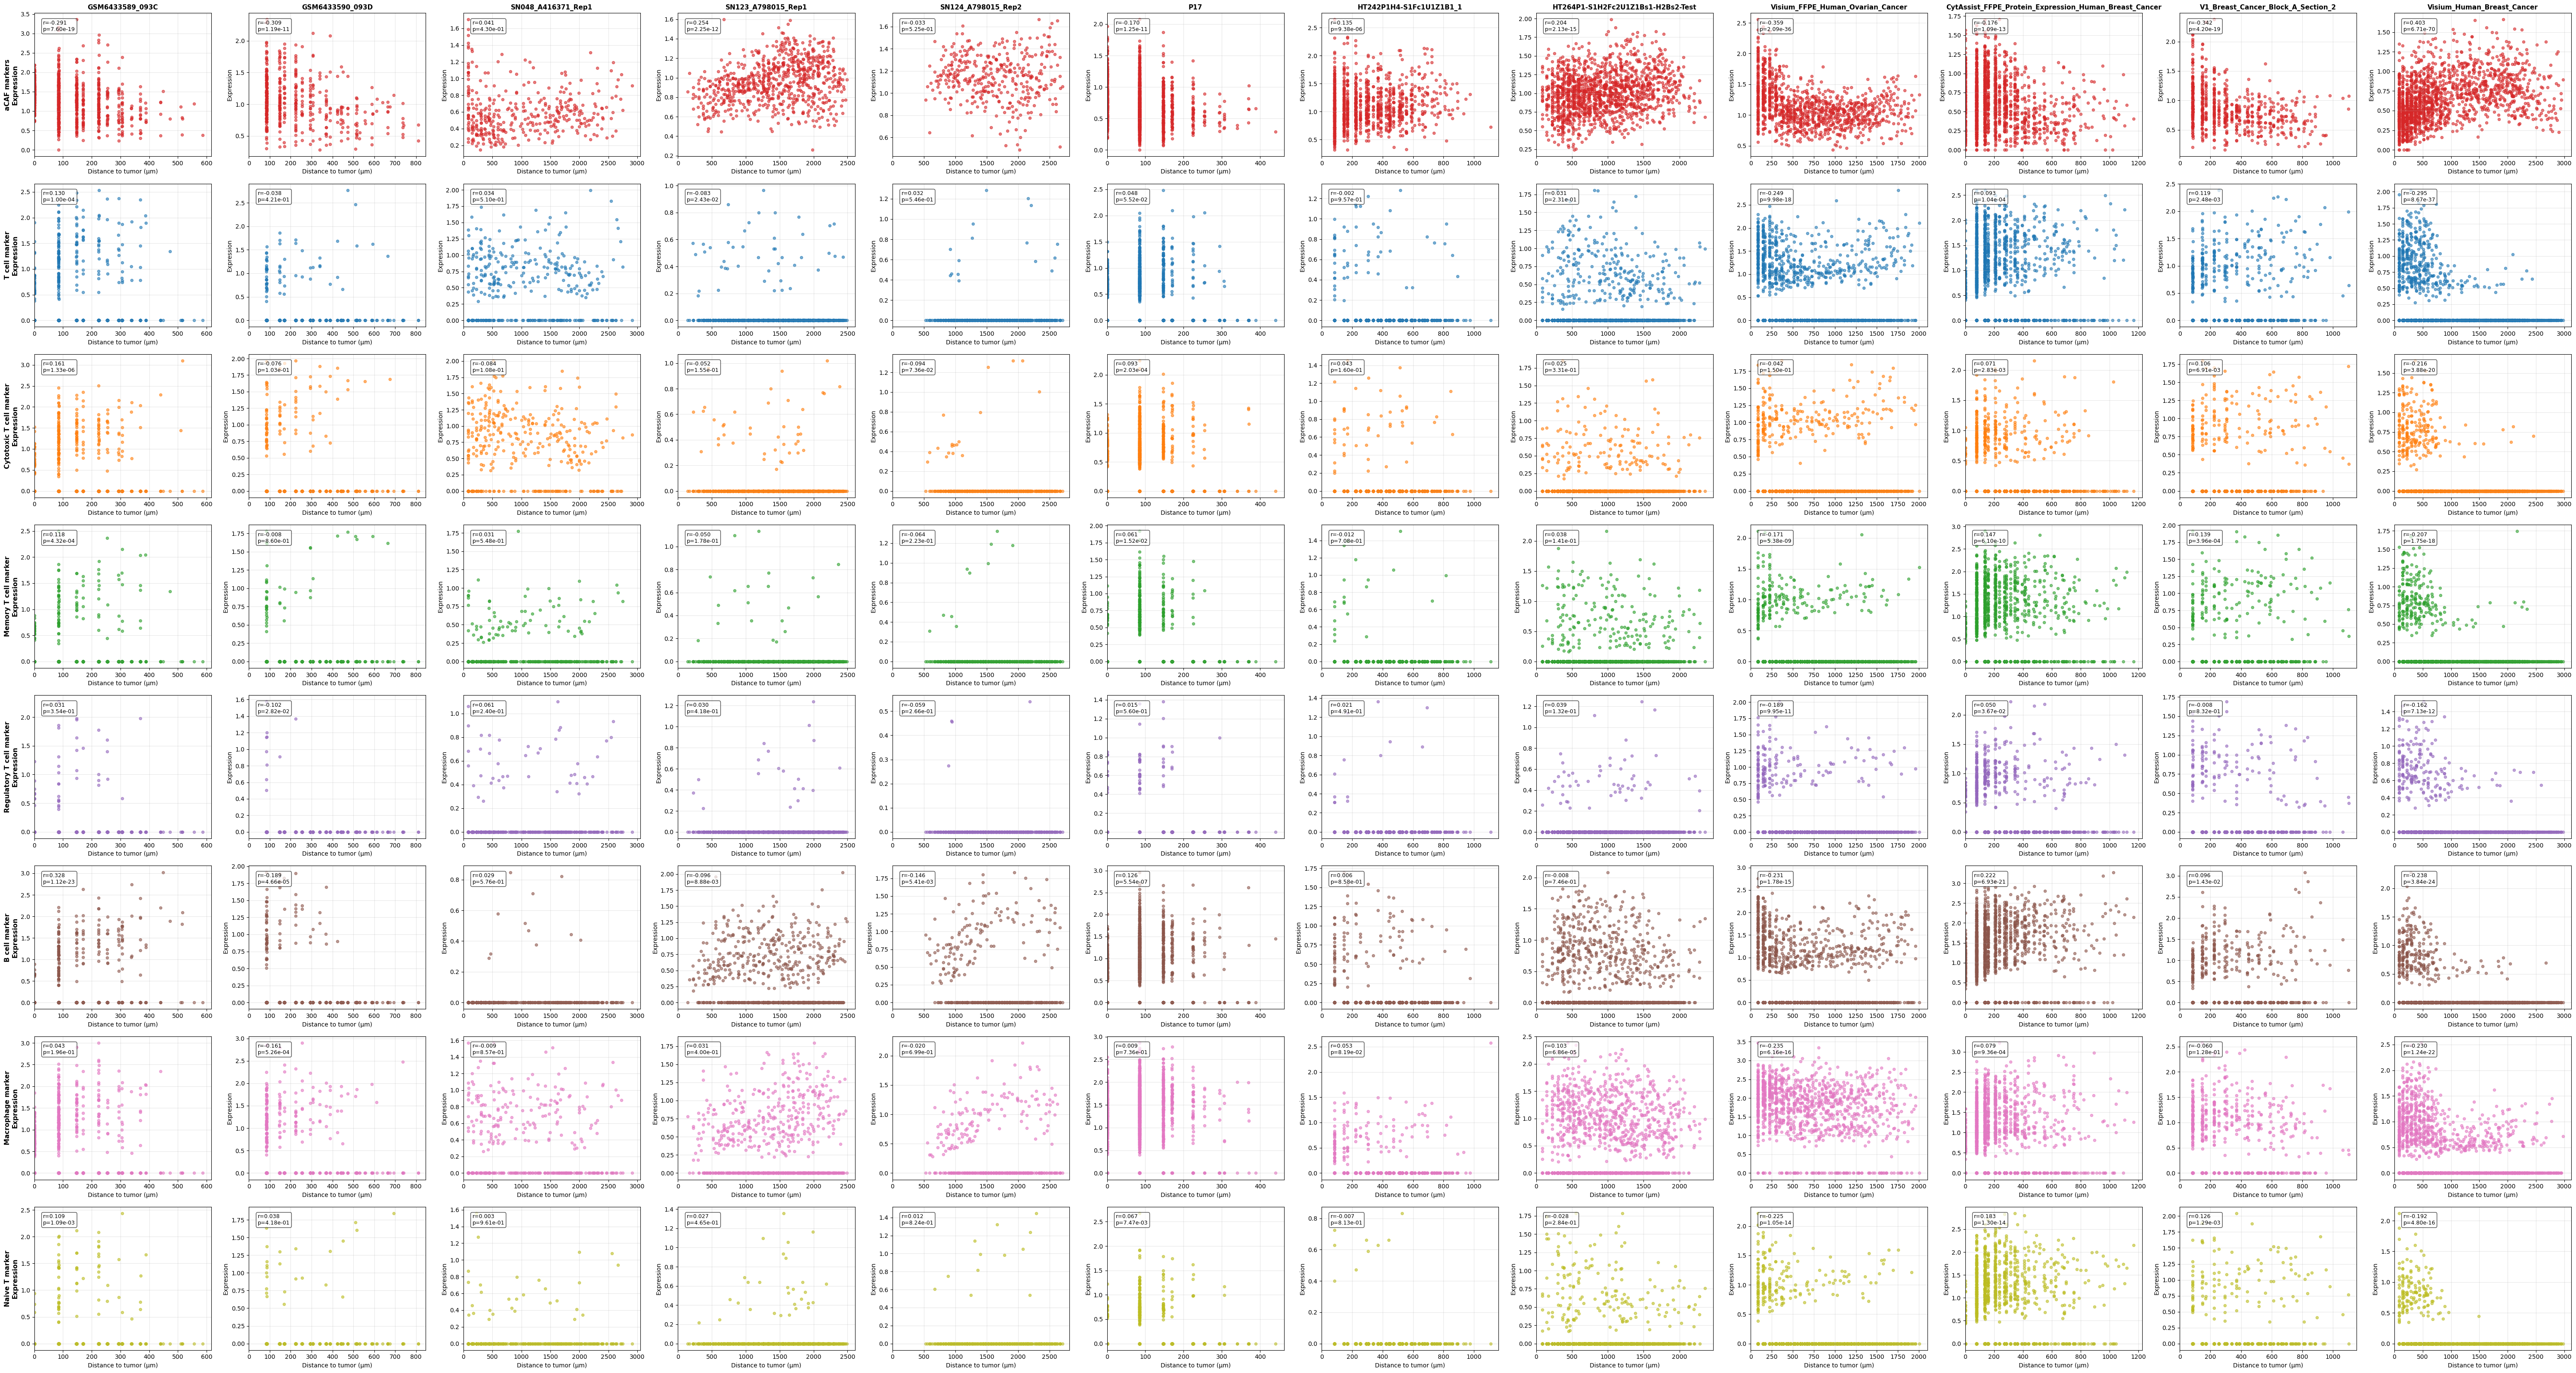

In [25]:
# ============= NEW: Multi-marker analysis configuration =============
# Define markers to analyze in order
MARKER_CONFIGS = [
    {
        'label': 'aCAF markers',
        'genes': ["COL11A1", "THBS2", "COL10A1", "COL5A2", "INHBA", "LRRC15", "COL5A1", "VCAN", "FAP", "COL1A1"],
        'color': "#d62728"  # brick red
    },
    {
        'label': 'T cell marker',
        'genes': ["CD3D"],
        'color': "#1f77b4"  
    },
    {
        'label': 'Cytotoxic T cell marker',
        'genes': ["CD8A"],
        'color': "#ff7f0e" 
    },
    {
        'label': 'Memory T cell marker',
        'genes': ["TCF7"],
        'color': "#2ca02c"  
    },
    {
        'label': 'Regulatory T cell marker',
        'genes': ["FOXP3"],
        'color': "#9467bd"  
    },
    {
        'label': 'B cell marker',
        'genes': ["CD79A"],
        'color': "#8c564b" 
    },
    {
        'label': 'Macrophage marker',
        'genes': ["CD163"],
        'color': "#e377c2" 
    },
    {
        'label': 'Naive T marker',
        'genes': ["CCR7"],
        'color': "#bcbd22" 
    }
]

def process_single_sample(dataset_name, sampleID, base_folder="/Volumes/T7/datasets"):
    """
    Load a single sample once and process all markers for that sample.
    Returns a list of results, one for each marker.
    """
    # Construct folder path
    folder = f"{base_folder}/{dataset_name}/raw/{sampleID}"
    
    try:
        # Load and process data ONCE
        print(f"  Loading data...")
        proc = tools.spatialTool()
        adata = proc.dataprocess(folder, skip_qc=False, verbose=False)
        
        # Identify STROMAL clusters (high LUM expression) - do this ONCE
        stromal_clusters = identify_clusters_by_expression(adata, STROMAL_MARKER, z_threshold=Z_THRESHOLD)
        
        # Automatically identify epithelial/tumor clusters (high EPCAM expression) - do this ONCE
        epithelial_clusters = identify_clusters_by_expression(adata, 'EPCAM', z_threshold=0.5)
        
        # Assign annotations based on identified clusters
        epithelial_spots = adata.obs['clusters'].isin(epithelial_clusters)
        stromal_spots = adata.obs['clusters'].isin(stromal_clusters)
        
        adata.obs['annotation_tumor'] = epithelial_spots
        adata.obs['annotation_stromal'] = stromal_spots
        
        # Get tumor coordinates and calculate distances to tumor ONCE
        coords = adata.obsm['spatial_um']
        tumor_indices = np.where(adata.obs['annotation_tumor'])[0]
        tumor_coords = coords[tumor_indices]
        
        # Calculate distance to nearest tumor for all spots
        all_distances_to_tumor = []
        for i, coord in enumerate(coords):
            if len(tumor_coords) > 0:
                distances_to_tumors = np.sqrt(np.sum((tumor_coords - coord)**2, axis=1))
                min_distance = np.min(distances_to_tumors)
            else:
                min_distance = np.inf
            all_distances_to_tumor.append(min_distance)
        all_distances_to_tumor = np.array(all_distances_to_tumor)
        
        # Get stromal mask and distances ONCE
        stromal_mask = adata.obs['annotation_stromal'].values
        stromal_distances = all_distances_to_tumor[stromal_mask]
        
        # Now process each marker
        results_for_sample = []
        
        for marker_config in MARKER_CONFIGS:
            print(f"    Processing {marker_config['label']}...")
            
            # Calculate expression score for this marker's genes
            expression_genes = marker_config['genes']
            present_expr_genes = [gene for gene in expression_genes if gene in adata.var_names]
            
            if len(present_expr_genes) == 0:
                print(f"      Warning: No genes found for {marker_config['label']}")
                continue
            
            # Calculate signature score for this marker
            marker_score_name = f"{marker_config['label']}_score"
            adata_subset = adata[:, present_expr_genes]
            signature_expr = adata_subset.X
            
            if hasattr(signature_expr, 'toarray'):
                signature_expr = signature_expr.toarray()
            
            marker_scores = np.mean(signature_expr, axis=1)
            
            # Get scores for stromal cells only
            stromal_scores = marker_scores[stromal_mask]
            
            # Calculate statistics if we have stromal data
            if len(stromal_distances) > 0 and len(stromal_scores) > 0:
                correlation_stromal, p_corr_stromal = stats.pearsonr(stromal_distances, stromal_scores)
                spearman_corr_stromal, p_spearman_stromal = stats.spearmanr(stromal_distances, stromal_scores)
            else:
                correlation_stromal, p_corr_stromal = np.nan, np.nan
                spearman_corr_stromal, p_spearman_stromal = np.nan, np.nan
            
            results_for_sample.append({
                'dataset': dataset_name,
                'sample': sampleID,
                'marker_label': marker_config['label'],
                'stromal_distances': stromal_distances,
                'stromal_scores': stromal_scores,
                'pearson_r': correlation_stromal,
                'pearson_p': p_corr_stromal,
                'spearman_r': spearman_corr_stromal,
                'spearman_p': p_spearman_stromal,
                'n_stromal': len(stromal_distances)
            })
        
        return results_for_sample
        
    except Exception as e:
        print(f"  Error processing {dataset_name}/{sampleID}: {str(e)}")
        return []

def create_multi_marker_plot(results_list, samples_list):
    """
    Create a grid plot with markers as rows and samples as columns
    results_list: list of dicts containing results for each marker-sample combination
    samples_list: list of sample IDs in order
    """
    n_markers = len(MARKER_CONFIGS)
    n_samples = len(samples_list)
    
    fig, axes = plt.subplots(n_markers, n_samples, figsize=(5*n_samples, 4*n_markers))
    
    # Handle case where we have only one row or column
    if n_markers == 1 and n_samples == 1:
        axes = np.array([[axes]])
    elif n_markers == 1:
        axes = axes.reshape(1, -1)
    elif n_samples == 1:
        axes = axes.reshape(-1, 1)
    
    # Process each combination
    for marker_idx, marker_config in enumerate(MARKER_CONFIGS):
        for sample_idx, sample_id in enumerate(samples_list):
            ax = axes[marker_idx, sample_idx]
            
            # Find the result for this marker-sample combination
            result = None
            for r in results_list:
                if r['sample'] == sample_id and r['marker_label'] == marker_config['label']:
                    result = r
                    break
            
            if result is not None and len(result['stromal_distances']) > 0:
                # Plot scatter
                ax.scatter(result['stromal_distances'], result['stromal_scores'], 
                          alpha=0.6, s=20, color=marker_config['color'])
                
                # Add correlation info
                r_val = result['pearson_r']
                p_val = result['pearson_p']
                if not np.isnan(r_val):
                    ax.text(0.05, 0.95, f"r={r_val:.3f}\np={p_val:.2e}", 
                           transform=ax.transAxes, fontsize=9, 
                           verticalalignment='top',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                
                ax.set_xlabel('Distance to tumor (μm)', fontsize=10)
                ax.set_ylabel('Expression', fontsize=10)
                ax.set_xlim(left=0)  # Set x-axis to start at 0, auto-scale the end
                ax.grid(True, alpha=0.3)
            else:
                # No data available
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                       ha='center', va='center', fontsize=12, color='gray')
                ax.set_xticks([])
                ax.set_yticks([])
            
            # Set titles
            if marker_idx == 0:
                ax.set_title(sample_id, fontsize=11, fontweight='bold')
            if sample_idx == 0:
                ax.set_ylabel(f"{marker_config['label']}\nExpression", fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    return fig

# ===================================================================
# MAIN PROCESSING FOR MULTI-MARKER ANALYSIS
# ===================================================================

print(f"Processing {len(df_filter_low_aCAF)} samples for {len(MARKER_CONFIGS)} markers...")
print(f"Optimized: Load each sample once, calculate all {len(MARKER_CONFIGS)} markers\n")

all_results_multi = []
samples_list = []

for idx, row in df_filter_low_aCAF.iterrows():
    dataset_name = row['dataset_name']
    sampleID = row['SampleID']
    samples_list.append(sampleID)
    
    print(f"===== {sampleID} =====")
    
    # Load sample ONCE and process ALL markers
    sample_results = process_single_sample(dataset_name, sampleID)
    all_results_multi.extend(sample_results)

print(f"\n{'='*60}")
print(f"Processing complete!")
print(f"Total results: {len(all_results_multi)} ({len(samples_list)} samples × {len(MARKER_CONFIGS)} markers)")
print(f"Data loads: {len(samples_list)} (vs {len(samples_list) * len(MARKER_CONFIGS)} in old approach)")
print(f"{'='*60}\n")

# Create the multi-marker plot
if len(all_results_multi) > 0:
    fig = create_multi_marker_plot(all_results_multi, samples_list)
    plt.show()
else:
    print("No results to plot")